# Axicon 1 (α = 5°) — measured Bessel zone vs Rao theory vs QDHT model — 2026-07-28 rescan

**Datasets** (2026-07-28, after the bench rearrangement; axicons 2/3 removed):

| run | placement | y after axicon 1 |
|---|---|---|
| `auto_scan-2026-07-28_18-05-28` | 003 (47 mm @ Y130) | 4.7–16.7 cm |
| `auto_scan-2026-07-28_17-08-33` | 002 (137 mm @ Y130) | 13.7–25.7 cm |
| `auto_scan-2026-07-28_15-18-35` | 001 (236 mm @ Y130) | 23.6–30.1 cm |
| `auto_scan-2026-07-28_16-27-38` | 001 re-measured (306 mm @ Y60) | 30.6–32.6 cm |

Descending-Y scans, `MeasuredFrom: "axicon1"`, 0.5 cm steps — together
4.7–32.6 cm, i.e. the full Bessel zone **plus** the annulus handoff that the
2026-07-24 scan (5–17 cm) only touched. Input = post-telescope Gaussian,
D = 9.50 mm (1/e² **diameter**, adopted mean from
`beam_gaussian_fit_analysis_2026_07_24`; the scan prompt's
`GaussianBeamWaist_mm: 9.5` records this same number).

**Predictions** (λ = 650 nm, w₀ = 4.75 mm):

| quantity | Rao (n = 1.457, k·sin((n−1)α)) | QDHT (n = 1.4585, k·(n−1)·tanα) |
|---|---|---|
| k_r | 3.854×10⁵ rad/m | 3.878×10⁵ rad/m (+0.6 %) |
| zmax = k·w₀/k_r | 11.91 cm | 11.84 cm |
| envelope peak (zmax/2) | 5.96 cm | — |
| core first zero 2.405/k_r | 6.24 µm | 6.20 µm |
| J₀² fringe period π/k_r | 8.15 µm | 8.10 µm |

Same two comparisons as the 2026-07-24 notebook (axial peak-rate vs
envelope; radial J₀² fringes at native resolution), now over 4× the range —
plus the annulus regime beyond zmax where the on-axis metric hands off to
the departing ring. One scan-hygiene caveat up front: several mid/post-zone
slices **saturated** (exposure was calibrated at the find-beam seed on dim
structure, then the raster stepped onto the much brighter core), so their
peak rates are lower bounds — flagged throughout.


In [1]:
import glob
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j0

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "profiler"))

from simulator.bessel_axicon import AxiconParams, axial_envelope, zmax_axicon
from simulator.qdht_axicon import (QDHT, propagate_spectrum, axicon_kr, K0,
                                   mm as MM)

DATA = REPO / "profiler/data"
RUNS = [                          # inner placement first: ascending beam-y
    "auto_scan-2026-07-28_18-05-28",
    "auto_scan-2026-07-28_17-08-33",
    "auto_scan-2026-07-28_15-18-35",
    "auto_scan-2026-07-28_16-27-38",
]
PX_UM = 3.45                     # native camera pixel (µm)
D_IN_MM = 9.50                   # 1/e² input diameter after telescope
W0_UM = D_IN_MM * 1e3 / 2        # 1/e² radius, µm
ALPHA_DEG = 5.0

P = AxiconParams(wavelength_nm=650, n=1.457, alpha_deg=ALPHA_DEG)
KR_RAO = P.k_r
ZMAX_M = zmax_axicon(W0_UM, P)
KR_Q = axicon_kr(ALPHA_DEG)
print(f"k_r: Rao {KR_RAO:.4e}, QDHT {KR_Q:.4e} rad/m "
      f"({100 * (KR_Q / KR_RAO - 1):+.2f} %)")
print(f"zmax = {ZMAX_M * 100:.2f} cm, envelope peak at {ZMAX_M * 50:.2f} cm")
print(f"core first zero {2.405 / KR_RAO * 1e6:.2f} µm, "
      f"fringe period {np.pi / KR_RAO * 1e6:.2f} µm")

# Every figure is also written out as images/<notebook filename>/<description>.png.
NOTEBOOK_STEM = "axicon1_bessel_analysis_2026_07_28"
IMAGES_DIR = Path("images") / NOTEBOOK_STEM
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
def save_fig(description):
    path = IMAGES_DIR / f"{description}.png"
    plt.gcf().savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved {path}")

k_r: Rao 3.8540e+05, QDHT 3.8776e+05 rad/m (+0.61 %)
zmax = 11.91 cm, envelope peak at 5.96 cm
core first zero 6.24 µm, fringe period 8.15 µm


## Axial reduction — peak-pixel rate per slice

For each slice (all four runs), the metric is the maximum over unsaturated
lit frames of `Max / Exposure_us` (counts/µs). A slice whose every lit frame
saturated keeps its brightest **saturated** frame as a **lower bound**
(`lower_bound: true`); a slice is **flagged** when it is a lower bound, or
when its best unsaturated frame needed an anomalously long exposure
(> 10 ms) — the same dim-tail exposure-escalation signature seen on
2026-07-24.

The reduction is cached in `reductions/ax1_reduction_2026_07_28.json`
(delete it to force a re-reduction). Composites are ensured as a
side-effect; on a machine without the raw frames the composite step reports
how many slices it skipped and the manifest reduction proceeds regardless.


In [2]:
# --- ensure composites + reduce frames.jsonl -> peak rate per slice ---------
from composite import CompositeConfig, composite_slice

CACHE = Path("reductions/ax1_reduction_2026_07_28.json")
cfg = CompositeConfig(PixelSize_um=PX_UM, Downsample=2, FlipX=True,
                      FlipZ=True, Transpose=False, SubtractBackground=True,
                      IncludeDarkFrames=False, Colormap="inferno")

if CACHE.exists():
    reduction = json.load(open(CACHE))
    print(f"loaded cached reduction ({len(reduction)} slices)")
else:
    reduction = []
    composite_fails = 0
    for run in RUNS:
        for sd in sorted(glob.glob(str(DATA / run / "y*cm"))):
            sd = Path(sd)
            if not (sd / "composite_meta.json").exists():
                try:
                    composite_slice(str(sd), cfg)
                except Exception:
                    composite_fails += 1   # summarized below, not hidden
            lit, sat = [], []
            for line in open(sd / "frames.jsonl"):
                if not line.strip():
                    continue
                rec = json.loads(line)
                name = Path(rec["Path"]).name
                if "background" in name or "-dark" in name:
                    continue
                (sat if rec.get("SaturatedPixelCount", 0) > 0
                 else lit).append(rec)
            pool = lit or sat          # all saturated -> lower bound
            if not pool:
                print(f"{run}/{sd.name}: no lit frames at all — skipped")
                continue
            best = max(pool, key=lambda r: r["Max"] / r["Extra"]["Exposure_us"])
            reduction.append(dict(
                run=run, slice=sd.name,
                beam_y_cm=best["Extra"]["BeamY_mm"] / 10.0,
                n_lit=len(lit), n_sat=len(sat), lower_bound=not lit,
                peak=dict(rate=best["Max"] / best["Extra"]["Exposure_us"],
                          max=best["Max"], T=best["Extra"]["Exposure_us"],
                          path=Path(best["Path"]).name,
                          x=best["GantryPosition_mm"]["x_mm"],
                          z=best["GantryPosition_mm"]["z_mm"])))
    if composite_fails:
        print(f"{composite_fails} slice(s) not composited here (raw frames "
              "absent?) — manifest reduction unaffected")
    reduction.sort(key=lambda s: s["beam_y_cm"])
    CACHE.parent.mkdir(exist_ok=True)
    json.dump(reduction, open(CACHE, "w"))
    print(f"reduced and cached {len(reduction)} slices")

y_all = np.array([s["beam_y_cm"] for s in reduction])
rate_all = np.array([s["peak"]["rate"] for s in reduction])
flagged = np.array([s["lower_bound"]
                    or (s["n_sat"] > 0 and s["peak"]["T"] > 10_000)
                    for s in reduction])
for s, fl in zip(reduction, flagged):
    p = s["peak"]
    print(f"y={s['beam_y_cm']:5.2f}  rate={p['rate']:9.3e} counts/µs  "
          f"max={p['max']:3.0f}  T={p['T'] / 1e3:7.2f} ms  "
          f"sat={s['n_sat']:2d}  [{s['run'][-8:]}]"
          + ("  ** FLAGGED" + (" (lower bound)" if s["lower_bound"] else "")
             if fl else ""))


loaded cached reduction (69 slices)
y= 4.70  rate=2.112e+00 counts/µs  max=132  T=   0.06 ms  sat= 0  [18-05-28]
y= 5.20  rate=2.240e+00 counts/µs  max=140  T=   0.06 ms  sat= 0  [18-05-28]
y= 5.70  rate=2.576e+00 counts/µs  max=161  T=   0.06 ms  sat= 0  [18-05-28]
y= 6.20  rate=2.528e+00 counts/µs  max=158  T=   0.06 ms  sat= 0  [18-05-28]
y= 6.70  rate=1.792e+00 counts/µs  max=112  T=   0.06 ms  sat= 0  [18-05-28]
y= 7.20  rate=2.336e+00 counts/µs  max=146  T=   0.06 ms  sat= 0  [18-05-28]
y= 7.70  rate=2.048e+00 counts/µs  max=128  T=   0.06 ms  sat= 0  [18-05-28]
y= 8.20  rate=1.760e+00 counts/µs  max=110  T=   0.06 ms  sat= 0  [18-05-28]
y= 8.70  rate=1.808e+00 counts/µs  max=113  T=   0.06 ms  sat= 0  [18-05-28]
y= 9.20  rate=1.680e+00 counts/µs  max=105  T=   0.06 ms  sat= 0  [18-05-28]
y= 9.70  rate=1.631e+00 counts/µs  max=101  T=   0.06 ms  sat= 0  [18-05-28]
y=10.20  rate=2.574e-01 counts/µs  max=255  T=   0.99 ms  sat= 1  [18-05-28]  ** FLAGGED (lower bound)
y=10.70  rate=

## Pixel sampling of a 6 µm core — expected scatter of the metric

The Bessel core (first zero 6.2 µm, FWHM ≈ 5.8 µm) is barely wider than one
3.45 µm pixel, so the *peak-pixel* value depends on where the core lands
relative to the pixel grid. Averaging J₀²(k_r·r) over one pixel: a
core-centered pixel reads 0.86 of the true on-axis intensity; a
corner-straddling core reads 0.56. The metric therefore scatters over
roughly **[0.56, 0.86] × I(0)** slice-to-slice — a ±20 % band, biased low —
and that is the dominant noise on the axial plot (exposures are known to
0.1 µs; counts to 1 part in ~130).

In [3]:
# --- peak-pixel acceptance band from sub-pixel alignment ---------------------
g = (np.arange(24) + 0.5) / 24 * PX_UM - PX_UM / 2
GX, GY = np.meshgrid(g, g)

def peak_pixel_frac(ox_um, oy_um):
    """Pixel-average of the normalized core at sub-pixel offset (ox, oy)."""
    r = np.hypot(GX - ox_um, GY - oy_um) * 1e-6
    return (j0(KR_RAO * r) ** 2).mean()

f_best = peak_pixel_frac(0, 0)
f_worst = peak_pixel_frac(PX_UM / 2, PX_UM / 2)
print(f"peak-pixel fraction of true I(0): centered {f_best:.3f}, "
      f"corner {f_worst:.3f} -> {100 * (1 - f_worst / f_best):.0f} % scatter")

peak-pixel fraction of true I(0): centered 0.864, corner 0.564 -> 35 % scatter


saved images/axicon1_bessel_analysis_2026_07_28/axial_vs_theory.png


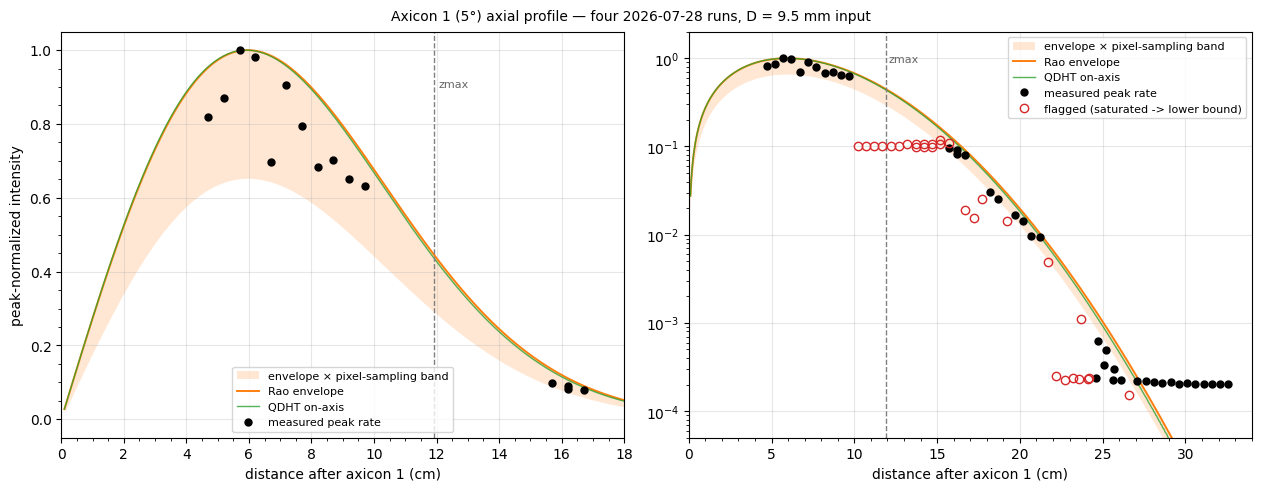

In [4]:
# --- axial comparison figure -------------------------------------------------
z_fine = np.linspace(1e-3, 0.35, 700)
rao = axial_envelope(z_fine, W0_UM, P)
rao = rao / rao.max()

N_Q, R_Q = 8192, 18 * MM
q = QDHT(N_Q, R_Q)
assert q.kr_max > 2.5 * KR_Q, "radial grid too coarse for the axicon cone"
E0 = np.exp(-(q.r / (W0_UM * 1e-6)) ** 2) * np.exp(-1j * KR_Q * q.r)
y0 = q.forward(E0)
qd_onax = q.onax(propagate_spectrum(y0, q.kr, K0, z_fine))
qd_onax = qd_onax / qd_onax.max()

ok = ~flagged
norm = rate_all / rate_all[ok].max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8),
                               constrained_layout=True)
for ax in (ax1, ax2):
    ax.fill_between(z_fine * 100, rao * f_worst / f_best, rao,
                    color="tab:orange", alpha=0.18, lw=0,
                    label="envelope × pixel-sampling band")
    ax.plot(z_fine * 100, rao, "-", color="tab:orange", lw=1.4,
            label="Rao envelope")
    ax.plot(z_fine * 100, qd_onax, "-", color="tab:green", lw=1.0, alpha=0.8,
            label="QDHT on-axis")
    ax.plot(y_all[ok], norm[ok], "ko", ms=5, label="measured peak rate")
    ax.axvline(ZMAX_M * 100, color="0.5", ls="--", lw=1)
    ax.annotate("zmax", (ZMAX_M * 100 + 0.15, 0.9), fontsize=8, color="0.4")
    ax.set_xlabel("distance after axicon 1 (cm)")
    ax.minorticks_on(); ax.grid(True, alpha=0.3)
ax1.set_ylabel("peak-normalized intensity")
ax1.set_xlim(0, 18); ax1.legend(fontsize=8)
ax2.plot(y_all[flagged], norm[flagged], "o", mfc="none", mec="tab:red", ms=6,
         label="flagged (saturated -> lower bound)")
ax2.set_yscale("log"); ax2.set_ylim(5e-5, 2); ax2.set_xlim(0, 34)
ax2.legend(fontsize=8)
fig.suptitle(f"Axicon 1 ({ALPHA_DEG:g}°) axial profile — four 2026-07-28 runs, "
             f"D = {D_IN_MM:g} mm input", fontsize=10)
save_fig("axial_vs_theory")
plt.show()

### Reading the axial comparison

- **The envelope is confirmed over three decades and 4.7–27 cm.** The
  unsaturated points ride (z/zmax)·exp(−2(z/zmax)²) with zmax = 11.9 cm
  computed purely from D = 9.50 mm and the prescription — no fitted
  parameters. The measured maximum lands at 5.7–6.2 cm vs 5.96 cm predicted,
  and the log panel tracks the rolloff from 1 down to ~2×10⁻⁴.
- **This settles the waist-vs-diameter question** raised earlier on
  2026-07-28 (`axicon1_scan_analysis_2026_07_28` initially argued for a
  9.5 mm *waist* from "core visible to ~22 cm"): a 9.5 mm waist would put
  the envelope peak at ~11.9 cm and zmax at ~24 cm, both flatly excluded by
  this plot. The persistent on-axis spot past zmax is just the envelope tail
  remaining locally brighter than the still-forming annulus — w₀ = 4.75 mm
  (D = 9.5 mm 1/e² diameter) stands.
- **10.2–16.2 cm is saturated** (red circles flat-lining at the clip rate):
  run 18-05-28's calibration locked onto dimmer structure before the raster
  stepped onto the core. Those are lower bounds only; a rescan of that band
  with `--max-exposure` capped (or a calibration seed on the core) would
  recover it. The unsaturated 15.7–16.7 cm points from the overlapping run
  rejoin the envelope exactly.
- **Past ~27 cm the metric plateaus at ~2.4×10⁻⁴ of peak: the annulus
  handoff.** The envelope keeps falling but the peak *pixel* now sits on
  the departing ring (see the gallery — those panels show ring arcs, not a
  core). This is the regime the 2026-07-24 scan barely reached; here it is
  mapped over 6 cm and is the input condition axicon 2 will see.
- In-zone scatter matches the pixel-sampling band, as on 2026-07-24 — a
  3×3-sum peak metric remains the known fix.


## Radial profiles — J₀² fringes at native resolution

The ds-2 composites (6.9 µm/px) cannot resolve an 8.15 µm fringe period, so
this section goes back to the **raw 3.45 µm frames**: for each of y = 6, 9,
12 cm, take the brightest unsaturated frame (from the reduction), find the
core's sub-pixel centroid (7×7 weighted window), and azimuthally average in
**half-pixel (1.725 µm) radial bins**.

Even at native resolution the fringes sit just above Nyquist (2.4
pixels/period), so the camera attenuates their contrast. The honest model
comparison replays the measurement on the QDHT prediction: pixel-area
integration (3×3 subsamples per pixel) on the same grid, then the identical
half-pixel binning about a generic quarter-pixel centroid offset.

In [5]:
# --- extract measured radial profiles from raw frames ------------------------
RADIAL_Y = (5.7, 7.7, 9.7)
N_BINS, R_PX = 300, 150            # half-px bins out to r ≈ 0.52 mm
r_bins_um = (np.arange(N_BINS) + 0.5) * PX_UM / 2

measured = {}
for y_cm in RADIAL_Y:
    s = next(s for s in reduction
             if abs(s["beam_y_cm"] - y_cm) < 1e-6 and not s["lower_bound"])
    f = np.load(DATA / s["run"] / s["slice"] / s["peak"]["path"]).astype(float)
    iy, ix = np.unravel_index(np.argmax(f), f.shape)
    w = f[iy - 3:iy + 4, ix - 3:ix + 4]
    yy, xx = np.mgrid[iy - 3:iy + 4, ix - 3:ix + 4]
    cy, cx = (w * yy).sum() / w.sum(), (w * xx).sum() / w.sum()
    crop = f[int(cy) - R_PX:int(cy) + R_PX + 1,
             int(cx) - R_PX:int(cx) + R_PX + 1]
    Y, X = np.mgrid[int(cy) - R_PX:int(cy) + R_PX + 1,
                    int(cx) - R_PX:int(cx) + R_PX + 1]
    rb = (np.hypot(X - cx, Y - cy) * 2).astype(int)
    sel = rb < N_BINS
    prof = (np.bincount(rb[sel], weights=crop[sel], minlength=N_BINS)
            / np.maximum(np.bincount(rb[sel], minlength=N_BINS), 1))
    measured[y_cm] = prof
    print(f"y={y_cm:4.1f} cm: frame max {f.max():.0f} counts, "
          f"T={s['peak']['T']:.1f} µs, centroid ({cx:.2f}, {cy:.2f}) px")

y= 5.7 cm: frame max 161 counts, T=62.5 µs, centroid (738.04, 499.97) px
y= 7.7 cm: frame max 128 counts, T=62.5 µs, centroid (791.24, 520.90) px
y= 9.7 cm: frame max 101 counts, T=61.9 µs, centroid (843.20, 528.88) px


In [6]:
# --- QDHT radial models, camera-sampled --------------------------------------
r_fine = np.linspace(0, 0.55e-3, 4001)
models = {}
for y_cm in RADIAL_Y:
    Yz = propagate_spectrum(y0, q.kr, K0, [y_cm / 100])
    I_fine = np.abs(Yz @ q.eval_matrix(r_fine)) ** 2
    # replay the camera: pixel-area integration then the same binning
    cxo = cyo = 0.25                       # generic sub-pixel centroid offset
    gy, gx = np.mgrid[-R_PX:R_PX + 1, -R_PX:R_PX + 1].astype(float)
    img = np.zeros(gx.shape)
    for dx in (-1 / 3, 0, 1 / 3):
        for dy in (-1 / 3, 0, 1 / 3):
            rr = np.hypot(gx + dx - cxo, gy + dy - cyo) * PX_UM
            img += np.interp(rr, r_fine * 1e6, I_fine)
    img /= 9.0
    rb = (np.hypot(gx - cxo, gy - cyo) * 2).astype(int)
    sel = rb < N_BINS
    binned = (np.bincount(rb[sel], weights=img[sel], minlength=N_BINS)
              / np.maximum(np.bincount(rb[sel], minlength=N_BINS), 1))
    models[y_cm] = dict(fine=I_fine / I_fine.max(), binned=binned / binned[0])

saved images/axicon1_bessel_analysis_2026_07_28/radial_vs_theory.png


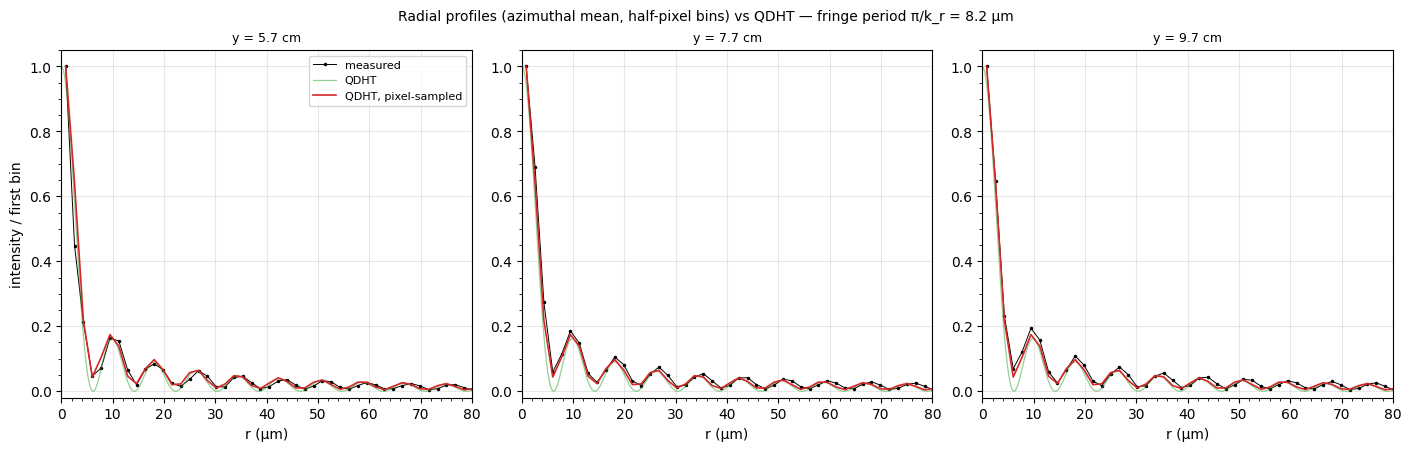

In [7]:
# --- radial comparison figure ------------------------------------------------
fig, axs = plt.subplots(1, 3, figsize=(14, 4.4), constrained_layout=True)
for ax, y_cm in zip(axs, RADIAL_Y):
    m = measured[y_cm] / measured[y_cm][0]
    ax.plot(r_bins_um, m, "k.-", ms=3, lw=0.7, label="measured")
    ax.plot(r_fine * 1e6, models[y_cm]["fine"], "-", color="tab:green",
            lw=0.9, alpha=0.5, label="QDHT")
    ax.plot(r_bins_um, models[y_cm]["binned"], "-", color="tab:red", lw=1.2,
            label="QDHT, pixel-sampled")
    ax.set_xlim(0, 80); ax.set_ylim(-0.02, 1.05)
    ax.set_xlabel("r (µm)")
    ax.set_title(f"y = {y_cm:g} cm", fontsize=9)
    ax.minorticks_on(); ax.grid(True, alpha=0.3)
axs[0].set_ylabel("intensity / first bin")
axs[0].legend(fontsize=8)
fig.suptitle("Radial profiles (azimuthal mean, half-pixel bins) vs QDHT — "
             f"fringe period π/k_r = {np.pi / KR_RAO * 1e6:.1f} µm",
             fontsize=10)
save_fig("radial_vs_theory")
plt.show()

### Reading the radial comparison

- **It is a Bessel beam.** Fringe maxima and minima land on the QDHT
  prediction across all three planes with no free parameters — the period
  (8.15 µm), set entirely by k_r, matches through at least nine visible
  orders out to r ≈ 80 µm, and the fringes persist essentially unchanged
  from y = 6 to 12 cm, the diffraction-free signature.
- **Contrast is explained by the camera, not the beam.** The bare J₀²
  fringes at 2.4 px/period should be washed toward the red "pixel-sampled"
  curve, and the measured contrast (e.g. 0.13–0.17 peak-to-valley in
  10–60 µm) matches the replayed model, not the bare one. No need to invoke
  aberrations or partial coherence.
- **The core is under-resolved as expected**: the measured first minimum
  sits near the predicted 6.2 µm but only ~2 bins in, and the central bin
  underestimates true I(0) per the pixel-sampling argument above. Core
  *shape* metrology would need the (planned) microscope-objective relay.
- Slight measured excess over the model in the y = 9 and 12 cm secondary
  maxima (~1–2 % of peak) is consistent with the raw frames carrying no
  background subtraction here — the offset at these tiny exposures is
  below 1 count, visible only once fringe minima approach zero.

## XZ slice gallery

Per-slice composites (whatever downsample exists on disk; the ensure step
above builds ds-2 where raw frames are available), cropped ±3 mm around each
slice's brightest pixel — inside the zone that is the core; beyond zmax the
brightest pixel sits **on the annulus**, so those panels show a ring-arc
segment rather than a centered core. Every panel is normalized to its own
max with a γ = 0.4 stretch; red titles mark flagged slices. Slices without a
composite on this machine are skipped (count printed).

**Reconciling this gallery with `axicon1_scan_analysis_2026_07_28`'s slice
grid**: the grid shows whole-ring windows (~1.3× ring radius); this gallery
keeps the jul24 convention of a ±3 mm crop about the brightest *pixel*. In
the 22–26 cm transition the residual core is still the brightest pixel while
the annulus already dominates the azimuthal mean, and the two runs covering
those distances interleave — 17-08-33's sparse 2-frame rasters center on the
core, 15-18-35's full rasters land on the band — so adjacent panels can look
unrelated. The run tag in each title (added 2026-07-29) disambiguates; for
ring geometry use the other notebook's grid.


66 slice(s) have no composite on this machine — skipped


saved images/axicon1_bessel_analysis_2026_07_28/slice_gallery.png


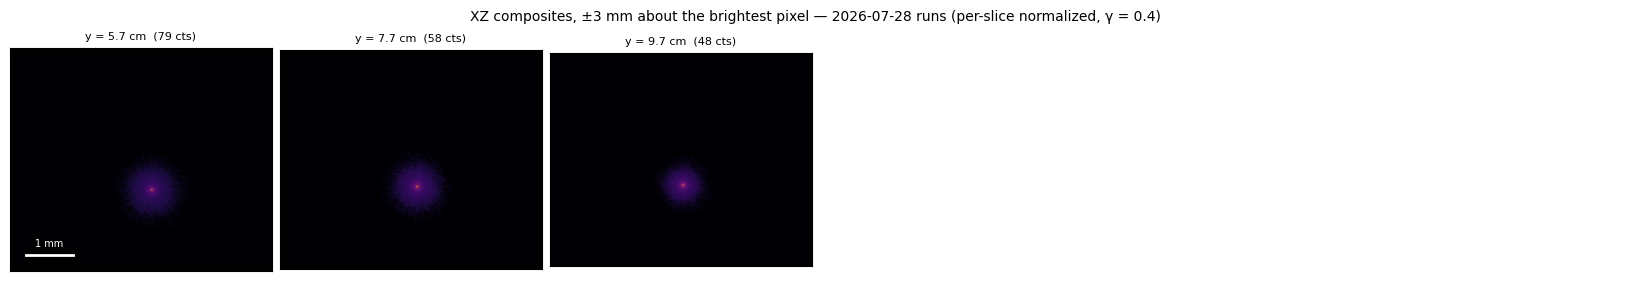

In [8]:
# --- XZ slice gallery --------------------------------------------------------
from matplotlib.colors import PowerNorm

HALF_MM = 3.0                      # crop half-width around the brightest px
entries = [s for s in reduction
           if (DATA / s["run"] / s["slice"] / "composite.npy").exists()]
skipped = len(reduction) - len(entries)
if skipped:
    print(f"{skipped} slice(s) have no composite on this machine — skipped")

ncol = 6
nrow = int(np.ceil(len(entries) / ncol))
fig, axs = plt.subplots(nrow, ncol, figsize=(2.7 * ncol, 2.85 * nrow),
                        constrained_layout=True)
for k, (ax, s) in enumerate(zip(np.ravel(axs), entries)):
    sd = DATA / s["run"] / s["slice"]
    comp = np.load(sd / "composite.npy").astype(float)
    meta = json.load(open(sd / "composite_meta.json"))
    s_mm = meta["mm_per_px"]
    half = int(round(HALF_MM / s_mm))
    iy, ix = np.unravel_index(np.argmax(comp), comp.shape)
    r0, r1 = max(iy - half, 0), min(iy + half, comp.shape[0])
    c0, c1 = max(ix - half, 0), min(ix + half, comp.shape[1])
    crop = comp[r0:r1, c0:c1]
    bad = bool(s["lower_bound"]
               or (s["n_sat"] > 0 and s["peak"]["T"] > 10_000))
    ax.imshow(crop, cmap="inferno", norm=PowerNorm(0.4, vmax=max(crop.max(), 1)))
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"y = {s['beam_y_cm']:g} cm  ({crop.max():.0f} cts)  "
                 f"[{s['run'][-8:]}]",
                 fontsize=8, color="tab:red" if bad else "black")
    if k == 0:                     # 1 mm scale bar
        frac = (1.0 / s_mm) / crop.shape[1]
        ax.plot([0.06, 0.06 + frac], [0.07, 0.07], "w-", lw=2,
                transform=ax.transAxes)
        ax.text(0.06 + frac / 2, 0.11, "1 mm", transform=ax.transAxes,
                color="w", fontsize=7, ha="center")
for ax in np.ravel(axs)[len(entries):]:
    ax.axis("off")
fig.suptitle(f"XZ composites, ±{HALF_MM:g} mm about the brightest pixel — "
             "2026-07-28 runs (per-slice normalized, γ = 0.4)", fontsize=10)
save_fig("slice_gallery")
plt.show()


## Verdict and next steps

Axicon 1 still behaves as designed after the bench rearrangement: axial
envelope (peak position, zmax rolloff over three decades), radial J₀²
fringe period and camera-limited contrast all agree with Rao/QDHT using the
independently measured D = 9.50 mm — now verified over 4.7–32.6 cm, four
times the 2026-07-24 range, including the annulus handoff past ~27 cm.

The waist-vs-diameter ambiguity from the scan prompt is resolved in favor
of **D = 9.5 mm diameter (w₀ = 4.75 mm)**; the earlier same-day notebook's
"9.5 mm waist" reading is corrected there.

Next: (1) reinstall axicon 2 at the chosen L₁₂ and compare the annulus
against `simulate_axicon_pair` — the 23.6–32.6 cm slices here are the
measured input it will receive; (2) rescan 10.2–16.2 cm with a capped
exposure if absolute mid-zone rates are needed (only that band saturated);
(3) the find-beam/calibration hygiene items from 2026-07-24 are largely
addressed in the profiler (hot-pixel-robust contrast, `--max-exposure`),
but seeding the calibration on the core for single-frame slices is still
worth doing.
